In [1]:
from numbers import Real
import numpy as np
from matplotlib import pyplot as plt
from numpy.polynomial import Chebyshev

In [2]:
from scipy.special import ellipe, ellipeinc
from numpy import pi, sin, cos
from scipy.optimize import newton

# From John D. Cook
def E_inverse(z, m):
    em = ellipe(m)
    t = (z/em)*(pi/2)
    f = lambda y: ellipeinc(y, m) - z
    r = newton(f, t)
    return r

In [3]:
vectorized_E_inverse = np.vectorize(E_inverse)

In [4]:
def get_approx_E_inverse(m: Real, deg: int = 14, n: int = 1001):
    """
    Chebyshev fit on [0, E(m)] with vectorized quadrant handling:
      - flip z locally only for odd quadrants
      - evaluate the polynomial once
      - for odd quadrants, map via (pi/2 - value)
    """
    # Evaluate the complete integral, which we'll need several times.
    E_m = ellipe(m)

    # fit the polynomial approximation on [0, E_m] (first quadrant.)
    x = np.linspace(0.0, E_m, num=n)
    y = vectorized_E_inverse(x, m)
    polynomial = Chebyshev.fit(x, y, deg=deg, domain=[0.0, E_m])

    def approx_E_inverse(z):
        # decompose z into z_local in [0, E_m] and a quadrant integer.
        z = np.asarray(z, dtype=float)
        quadrant = np.floor(z / E_m).astype(np.int64)
        z_local = z - quadrant * E_m

        # we need to do a complementary angle trick to handle odd quadrants.
        # vectorized mask, 1 for odd quadrants, 0 for even.
        odd = (quadrant % 2).astype(bool)

        # flip odd quadrants,  evaluate polynomial, then flip them back.
        z_for_poly = np.where(odd, E_m - z_local, z_local)
        phi_raw = polynomial(z_for_poly)
        phi = np.where(odd, (np.pi / 2.0) - phi_raw, phi_raw)

        # add the quadrant back on to get the global angle
        theta = quadrant * (np.pi / 2.0) + phi
        
        return theta

    return approx_E_inverse

In [5]:
def plot_E_inverse_approximation(m: Real, deg: int=14, n: int=1001, ylim=None):
    """
    Plots the exact `ellipeinc()` curve, the inverse
    calculated with Newton's method, and the Chebyshev
    approximation to the same on the same axes.
    """
    E_m = ellipe(m)

    if ylim is None:
        ylim = (0, E_m)
    x = np.linspace(ylim[0], ylim[1], num=n)
    y = vectorized_E_inverse(x, m)
    approx_E_inverse = get_approx_E_inverse(m, deg=deg, n=n)
    approx_y = approx_E_inverse(x)

    exact_x = ellipeinc(y, m)
    slope = float(y[-1] / exact_x[-1])
    exact_error = np.max(np.abs(x - exact_x)) * slope
    chebyshev_error = np.max(np.abs(approx_y - y))

    plt.plot(exact_x, y, label="Exact")
    plt.plot(x, y, label=f"Newton's Method  ({exact_error:0.1e})")
    plt.plot(x, approx_y, label=f"Chebyshev ({chebyshev_error:0.1e})")
    plt.legend()
    
    return chebyshev_error, exact_error

(4.4499052709312537e-07, 1.1533667557464777e-13)

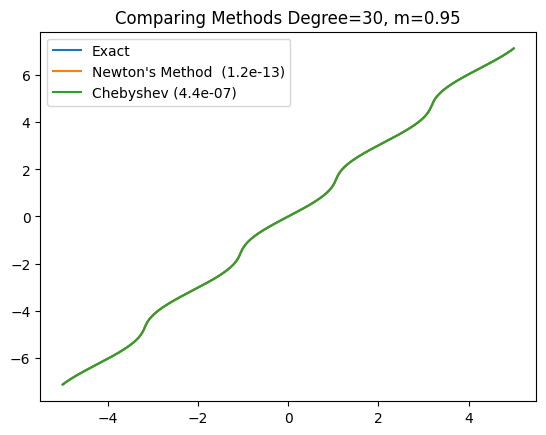

In [6]:
plt.title("Comparing Methods Degree=30, m=0.95")
plot_E_inverse_approximation(m=0.95, deg=30, ylim=(-5, +5))

4.179843019702645e-06

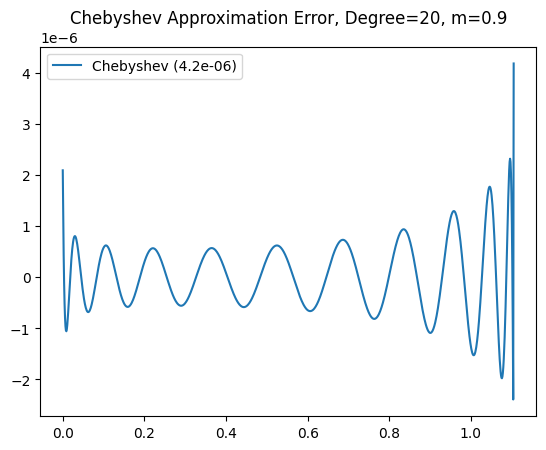

In [7]:
def plot_E_inverse_error(m: Real, deg: int=14, n: int=1001):
    """
    Plot the error of the approximation over one quadrant.
    """
    E_m = ellipe(m)

    x = np.linspace(0, E_m, num=n)
    y = vectorized_E_inverse(x, m)
    approx_E_inverse = get_approx_E_inverse(m, deg=deg, n=n)
    approx_y = approx_E_inverse(x)

    error = approx_y - y
    max_absolute_error = np.max(np.abs(error))

    plt.plot(x, approx_y - y, label=f"Chebyshev ({max_absolute_error:0.1e})")
    plt.legend()

    return max_absolute_error

plt.title("Chebyshev Approximation Error, Degree=20, m=0.9")
plot_E_inverse_error(0.9, deg=20)

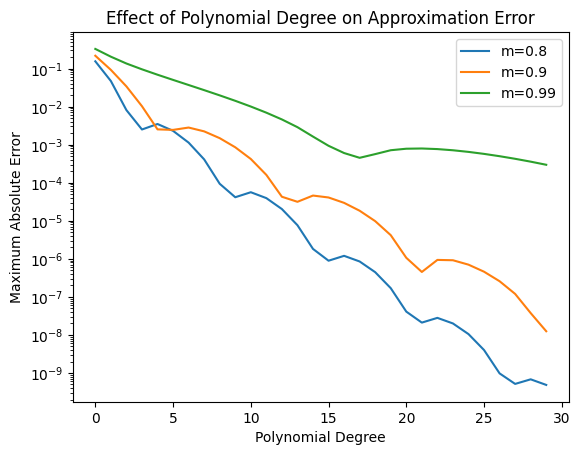

In [8]:
# vary the polynomial degree and measure error
for m in [0.8, 0.9, 0.99]:
    E_m = ellipe(m)
    x = np.linspace(0, E_m, num=1001)
    y = vectorized_E_inverse(x, m)
    errors = []
    for deg in range(1, 31):
        approx_E_inverse = get_approx_E_inverse(m, deg=deg, n=1001)
        approx_y = approx_E_inverse(x)
        error = np.max(np.abs(approx_y - y))
        errors.append(error)
    plt.plot(errors, label=f"m={m}")

plt.legend()
plt.yscale("log")
plt.xlabel("Polynomial Degree")
plt.ylabel("Maximum Absolute Error")
plt.title("Effect of Polynomial Degree on Approximation Error");

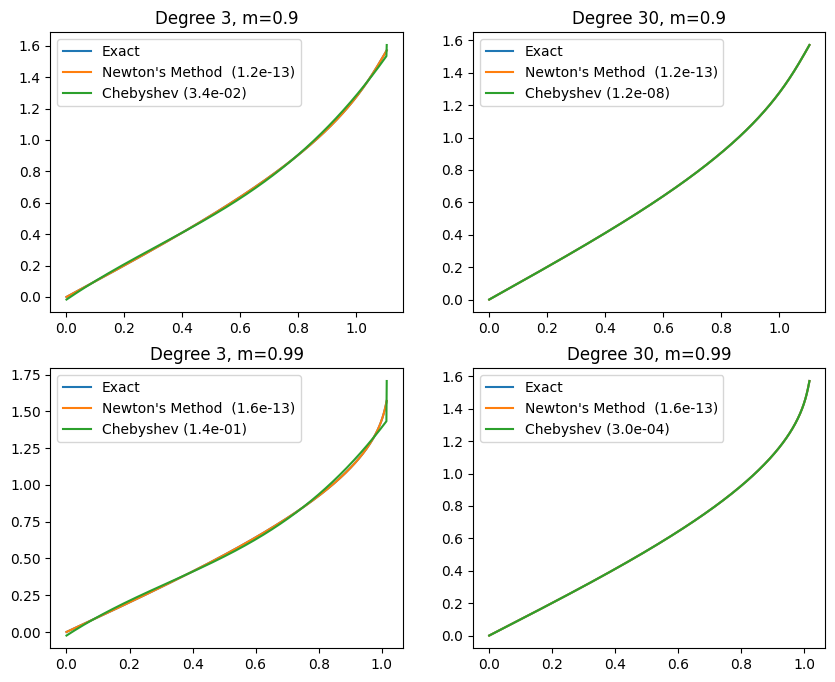

In [9]:
# vary both m and and degree and plot curves and error
plt.figure(figsize=(10, 8))
plt.tight_layout()

for i, m in enumerate([0.9, 0.99]):
    for j, deg in enumerate([3, 30]):
        plot_index = 2 * i + j + 1
        plt.subplot(2, 2, plot_index)
        plot_E_inverse_approximation(m, deg=deg)
        plt.title(f"Degree {deg}, m={m}")


In [10]:
m = 0.95
E_m = ellipe(m)
x = np.linspace(0, E_m, num=1001)

In [11]:
%%timeit -n 3 -r 3
y = vectorized_E_inverse(x, m)

205 ms ± 6.5 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [12]:
approx_E_inverse = get_approx_E_inverse(m, deg=10, n=1001)

In [13]:
%%timeit -n 10 -r 10
y = approx_E_inverse(x)

109 µs ± 41.1 µs per loop (mean ± std. dev. of 10 runs, 10 loops each)


In [14]:
approx_E_inverse = get_approx_E_inverse(m, deg=30, n=1001)

In [15]:
%%timeit -n 10 -r 10
y = approx_E_inverse(x)

218 µs ± 21.4 µs per loop (mean ± std. dev. of 10 runs, 10 loops each)
